# H-1B LCA Analysis — FY2020–2026 Q1 (all quarters)
Reads all pre-processed CSVs produced by `xlsx_to_csv.py`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

CSV_DIR  = Path('csv')
UNIT_MULT = {'Year': 1, 'Month': 12, 'Bi-Weekly': 26, 'Week': 52, 'Hour': 2080}

## Load & combine all quarters

In [2]:
frames = []
for path in sorted(CSV_DIR.glob('lca_disclosure_fy*.csv')):
    # filename: lca_disclosure_fy2026_q1.csv  →  period = '2026_Q1'
    stem    = path.stem.replace('lca_disclosure_fy', '').upper()  # '2026_Q1'
    fy, q   = stem.split('_')
    chunk   = pd.read_csv(path, low_memory=False)
    chunk['FISCAL_YEAR'] = int(fy)
    chunk['QUARTER']     = q
    chunk['PERIOD']      = f'FY{fy} {q}'
    frames.append(chunk)
    print(f"  {path.name:<45} {len(chunk):>7,} rows")

df = pd.concat(frames, ignore_index=True)
print(f"\nTotal rows: {len(df):,}  |  Quarters loaded: {len(frames)}")

  lca_disclosure_fy2020_q1.csv                  112,017 rows


  lca_disclosure_fy2020_q2.csv                  157,173 rows


  lca_disclosure_fy2020_q3.csv                  190,749 rows


  lca_disclosure_fy2020_q4.csv                  117,395 rows


  lca_disclosure_fy2021_q1.csv                   80,622 rows


...

  lca_disclosure_fy2025_q2.csv                  132,133 rows


  lca_disclosure_fy2025_q3.csv                  238,425 rows


  lca_disclosure_fy2025_q4.csv                  118,580 rows


  lca_disclosure_fy2026_q1.csv                   83,120 rows



Total rows: 3,915,039  |  Quarters loaded: 25


In [3]:
# Derived columns used throughout
df['EMPLOYER_NORM']    = df['EMPLOYER_NAME'].fillna('UNKNOWN').str.strip().str.upper()
df['annual_wage']      = df['WAGE_RATE_OF_PAY_FROM'] * df['WAGE_UNIT_OF_PAY'].map(UNIT_MULT)
df['annual_pw']        = df['PREVAILING_WAGE']        * df['PW_UNIT_OF_PAY'].map(UNIT_MULT)
df['wage_premium_pct'] = (df['annual_wage'] - df['annual_pw']) / df['annual_pw'] * 100

print("VISA_CLASS breakdown (all time):")
print(df['VISA_CLASS'].value_counts())
print("\nCASE_STATUS breakdown (all time):")
print(df['CASE_STATUS'].value_counts())

VISA_CLASS breakdown (all time):


VISA_CLASS
H-1B               3814684
E-3 Australian       76922
H-1B1 Chile          13358
H-1B1 Singapore      10075
Name: count, dtype: int64

CASE_STATUS breakdown (all time):


CASE_STATUS
Certified                3624066
Certified - Withdrawn     197952
Withdrawn                  69786
Denied                     23235
Name: count, dtype: int64


## Overall employer ranking (all quarters combined)

In [4]:
grp_all = (
    df.groupby('EMPLOYER_NORM')
    .agg(
        petitions          = ('CASE_NUMBER',           'count'),
        total_workers      = ('TOTAL_WORKER_POSITIONS','sum'),
        new_hires          = ('NEW_EMPLOYMENT',        'sum'),
        certified          = ('CASE_STATUS',           lambda s: s.str.startswith('Certified').sum()),
        median_annual_wage = ('annual_wage',           'median'),
        median_premium_pct = ('wage_premium_pct',      'median'),
    )
    .reset_index()
    .sort_values('petitions', ascending=False)
    .reset_index(drop=True)
)
grp_all['cert_rate_%']   = (grp_all['certified']  / grp_all['petitions'] * 100).round(1)
grp_all['new_hire_rate'] = (grp_all['new_hires']  / grp_all['petitions'] * 100).round(1)

print(f"Unique employers: {len(grp_all):,}")
grp_all.head(20)

Unique employers: 194,539


,EMPLOYER_NORM,petitions,total_workers,new_hires,certified,median_annual_wage,median_premium_pct,cert_rate_%,new_hire_rate
0,COGNIZANT TECHNOLOGY SOLUTIONS US CORP,101857,102032,17524,100608,93600.00,0.000000,98.8,17.2
1,AMAZON.COM SERVICES LLC,89110,493470,266319,88407,144626.00,23.173809,99.2,298.9
2,GOOGLE LLC,68732,68732,29079,67861,162000.00,19.944382,98.7,42.3
3,ERNST & YOUNG U.S. LLP,64193,64283,19321,63178,129300.08,33.183306,98.4,30.1
4,TATA CONSULTANCY SERVICES LIMITED,63907,71219,20719,63615,77750.00,0.000000,99.5,32.4
5,MICROSOFT CORPORATION,61117,127044,77780,61115,155305.00,25.118640,100.0,127.3
6,INFOSYS LIMITED,46516,340622,110612,46280,86965.00,0.000000,99.5,237.8
7,APPLE INC.,33507,142625,25766,33241,168709.00,5.039976,99.2,76.9
8,DELOITTE CONSULTING LLP,30860,53959,7422,30685,122300.00,13.756107,99.4,24.1
9,ACCENTURE LLP,26406,26803,7663,26038,107293.00,3.201517,98.6,29.0


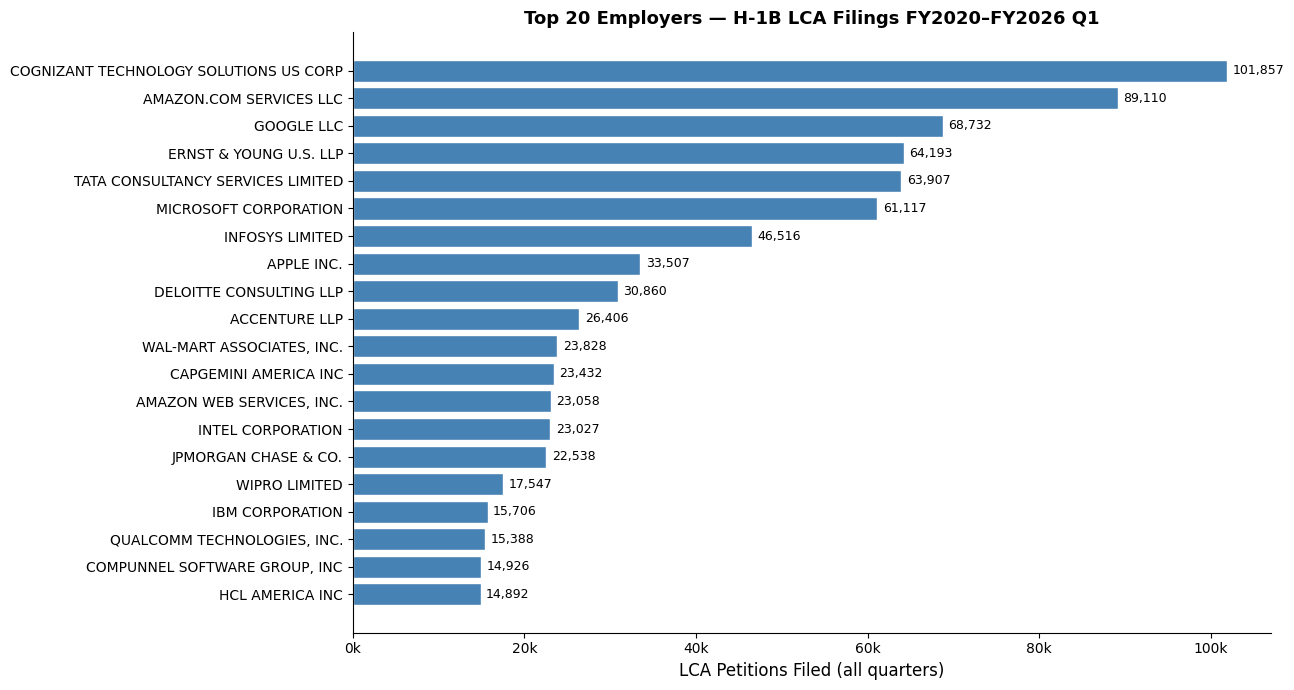

In [5]:
top20 = grp_all.head(20)

fig, ax = plt.subplots(figsize=(13, 7))
bars = ax.barh(top20['EMPLOYER_NORM'].str[:42], top20['petitions'],
               color='steelblue', edgecolor='white')
ax.invert_yaxis()
ax.set_xlabel('LCA Petitions Filed (all quarters)', fontsize=12)
ax.set_title('Top 20 Employers — H-1B LCA Filings FY2020–FY2026 Q1', fontsize=13, fontweight='bold')
ax.bar_label(bars, fmt='{:,.0f}', padding=4, fontsize=9)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('top20_employers_all.png', dpi=150)
plt.show()

## Petition volume trend — total market by quarter

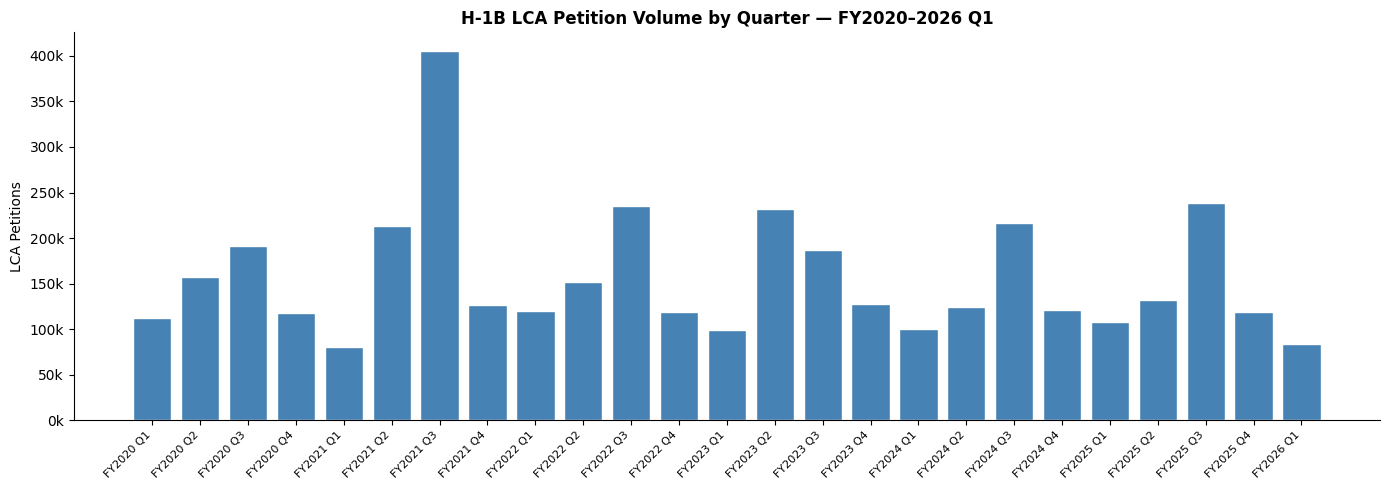

,FISCAL_YEAR,QUARTER,petitions,total_workers,period_label
0,2020,Q1,112017,163530,FY2020 Q1
1,2020,Q2,157173,276593,FY2020 Q2
2,2020,Q3,190749,278705,FY2020 Q3
3,2020,Q4,117395,160657,FY2020 Q4
4,2021,Q1,80622,204787,FY2021 Q1
5,2021,Q2,213481,517722,FY2021 Q2
6,2021,Q3,405626,857243,FY2021 Q3
7,2021,Q4,126576,214261,FY2021 Q4
8,2022,Q1,120306,220758,FY2022 Q1
9,2022,Q2,151603,305548,FY2022 Q2


In [6]:
period_totals = (
    df.groupby(['FISCAL_YEAR', 'QUARTER'])
    .agg(petitions=('CASE_NUMBER', 'count'),
         total_workers=('TOTAL_WORKER_POSITIONS', 'sum'))
    .reset_index()
    .sort_values(['FISCAL_YEAR', 'QUARTER'])
)
period_totals['period_label'] = 'FY' + period_totals['FISCAL_YEAR'].astype(str) + ' ' + period_totals['QUARTER']

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(period_totals['period_label'], period_totals['petitions'], color='steelblue', edgecolor='white')
ax.set_ylabel('LCA Petitions')
ax.set_title('H-1B LCA Petition Volume by Quarter — FY2020–2026 Q1', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
plt.xticks(rotation=45, ha='right', fontsize=8)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('petition_volume_by_quarter.png', dpi=150)
plt.show()

period_totals

## Hiring trend — top public companies over time

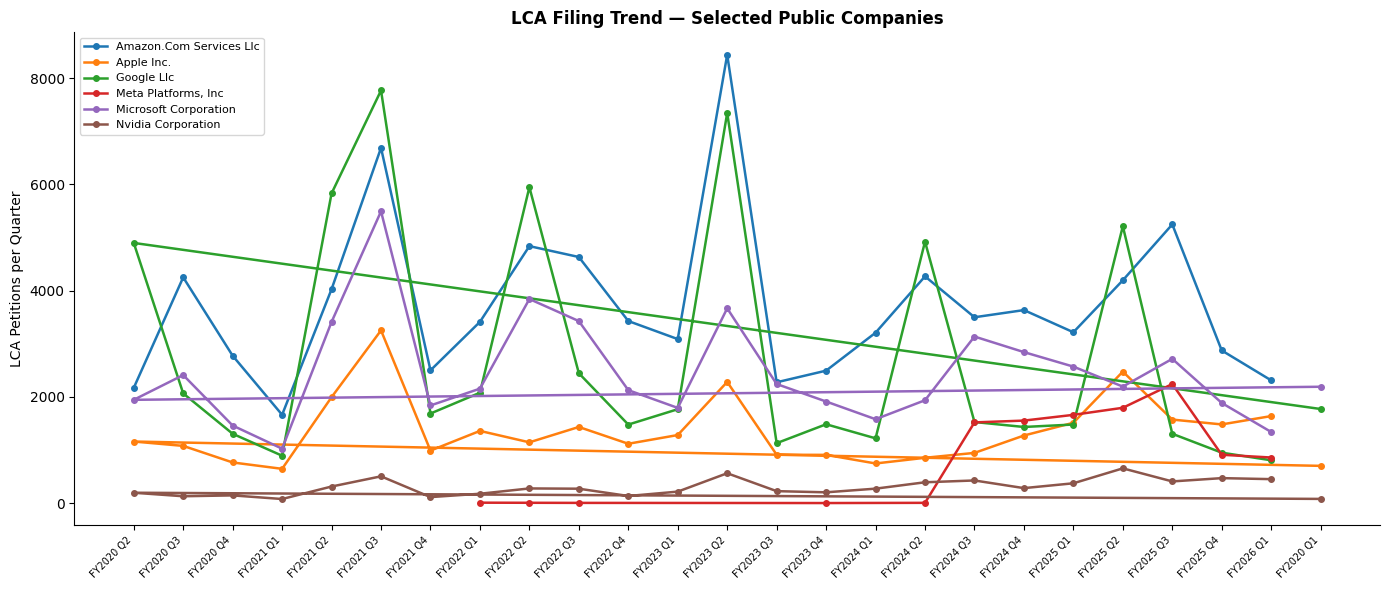

In [7]:
FOCUS_COS = [
    'AMAZON.COM SERVICES LLC',
    'MICROSOFT CORPORATION',
    'APPLE INC.',
    'GOOGLE LLC',
    'META PLATFORMS, INC',
    'NVIDIA CORPORATION',
]

trend = (
    df[df['EMPLOYER_NORM'].isin(FOCUS_COS)]
    .groupby(['EMPLOYER_NORM', 'FISCAL_YEAR', 'QUARTER'])
    .agg(petitions=('CASE_NUMBER', 'count'),
         new_hires=('NEW_EMPLOYMENT', 'sum'),
         median_wage=('annual_wage', 'median'))
    .reset_index()
    .sort_values(['EMPLOYER_NORM', 'FISCAL_YEAR', 'QUARTER'])
)
trend['period_label'] = 'FY' + trend['FISCAL_YEAR'].astype(str) + ' ' + trend['QUARTER']

companies = trend['EMPLOYER_NORM'].unique()
fig, ax = plt.subplots(figsize=(14, 6))
for co in companies:
    sub = trend[trend['EMPLOYER_NORM'] == co]
    ax.plot(sub['period_label'], sub['petitions'], marker='o', linewidth=1.8,
            markersize=4, label=co.title()[:30])

ax.set_ylabel('LCA Petitions per Quarter')
ax.set_title('LCA Filing Trend — Selected Public Companies', fontweight='bold')
ax.legend(fontsize=8, loc='upper left')
plt.xticks(rotation=45, ha='right', fontsize=7)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('hiring_trend_public_cos.png', dpi=150)
plt.show()

## Median offered wage trend — same companies

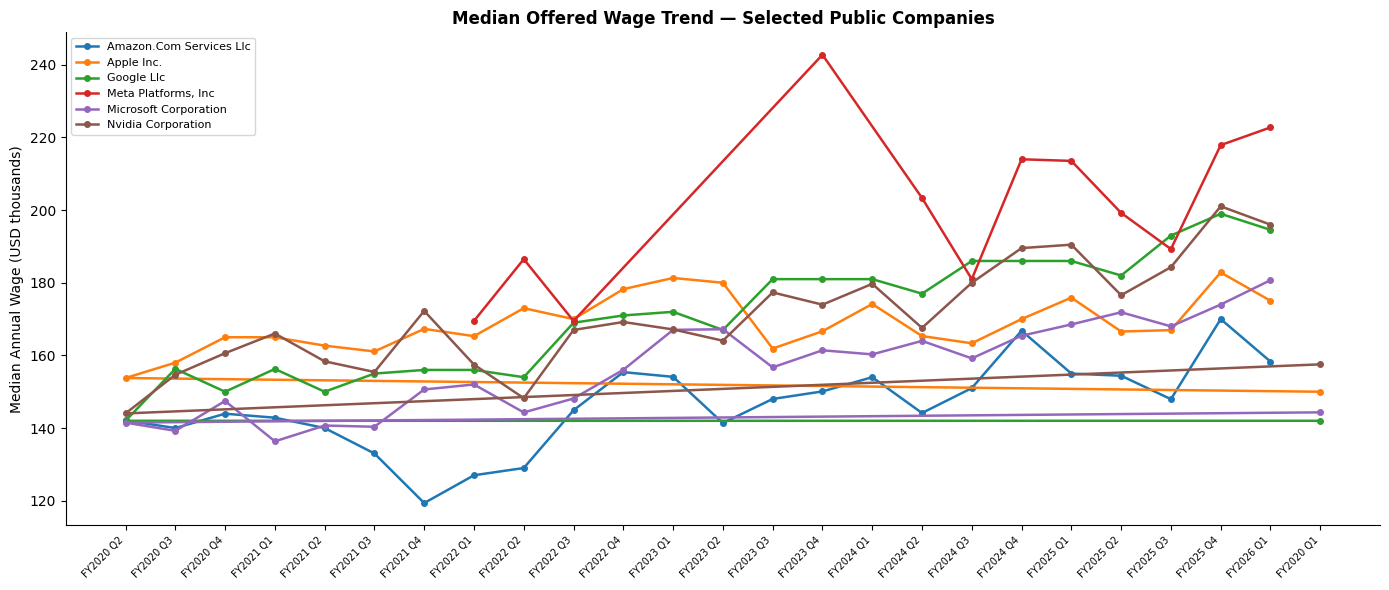

In [8]:
fig, ax = plt.subplots(figsize=(14, 6))
for co in companies:
    sub = trend[trend['EMPLOYER_NORM'] == co].dropna(subset=['median_wage'])
    ax.plot(sub['period_label'], sub['median_wage'] / 1000, marker='o',
            linewidth=1.8, markersize=4, label=co.title()[:30])

ax.set_ylabel('Median Annual Wage (USD thousands)')
ax.set_title('Median Offered Wage Trend — Selected Public Companies', fontweight='bold')
ax.legend(fontsize=8, loc='upper left')
plt.xticks(rotation=45, ha='right', fontsize=7)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('wage_trend_public_cos.png', dpi=150)
plt.show()

## Investment summary table — latest quarter vs all-time

In [9]:
latest_period = df['PERIOD'].max()
df_latest = df[df['PERIOD'] == latest_period]

def summary_table(data):
    return (
        data.groupby('EMPLOYER_NORM')
        .agg(
            petitions          = ('CASE_NUMBER',           'count'),
            new_hires          = ('NEW_EMPLOYMENT',        'sum'),
            total_workers      = ('TOTAL_WORKER_POSITIONS','sum'),
            median_wage_k      = ('annual_wage',           lambda x: round(x.median() / 1000, 0)),
            median_premium_pct = ('wage_premium_pct',      lambda x: round(x.median(), 1)),
            senior_share_pct   = ('PW_WAGE_LEVEL',         lambda x: round(x.isin(['III','IV']).mean() * 100, 1)),
            tech_role_pct      = ('SOC_CODE',              lambda x: round(x.astype(str).str.startswith('15-').mean() * 100, 1)),
        )
        .sort_values('petitions', ascending=False)
        .reset_index()
    )

PUBLIC_COS = [
    'AMAZON.COM SERVICES LLC', 'AMAZON WEB SERVICES, INC.',
    'APPLE INC.', 'MICROSOFT CORPORATION', 'GOOGLE LLC',
    'META PLATFORMS, INC', 'NVIDIA CORPORATION',
    'JPMORGAN CHASE & CO.',
]

latest_tbl = summary_table(df_latest[df_latest['EMPLOYER_NORM'].isin(PUBLIC_COS)])
latest_tbl.columns = ['Company','Petitions','New Hires','Workers',
                       'Median Wage ($k)','Wage Premium %','Senior %','Tech Role %']
print(f"Latest period: {latest_period}")
latest_tbl

Latest period: FY2026 Q1


,Company,Petitions,New Hires,Workers,Median Wage ($k),Wage Premium %,Senior %,Tech Role %
0,AMAZON.COM SERVICES LLC,2310,712,10616,158.0,11.2,27.7,74.2
1,APPLE INC.,1638,488,1638,175.0,0.0,40.8,55.9
2,MICROSOFT CORPORATION,1338,110,1338,181.0,13.5,60.2,85.8
3,"META PLATFORMS, INC",858,34,1098,223.0,16.0,64.9,78.2
4,GOOGLE LLC,806,28,806,195.0,10.9,40.9,80.1
5,"AMAZON WEB SERVICES, INC.",568,168,2899,158.0,13.8,31.7,91.2
6,JPMORGAN CHASE & CO.,527,14,527,163.0,14.5,57.9,86.0
7,NVIDIA CORPORATION,451,1091,2601,196.0,0.0,56.8,51.9


## Verify: FY2026 Q1 matches standalone xlsx notebook

In [10]:
# Re-run top-20 groupby directly from xlsx for FY2026 Q1
df_xlsx = pd.read_excel(
    'dol_2026Q1/LCA_Disclosure_Data_FY2026_Q1.xlsx', engine='openpyxl',
    usecols=['CASE_NUMBER','EMPLOYER_NAME','TOTAL_WORKER_POSITIONS','NEW_EMPLOYMENT','CASE_STATUS']
)
df_xlsx['EMPLOYER_NORM'] = df_xlsx['EMPLOYER_NAME'].fillna('UNKNOWN').str.strip().str.upper()
grp_xlsx = (
    df_xlsx.groupby('EMPLOYER_NORM')
    .agg(petitions=('CASE_NUMBER','count'), total_workers=('TOTAL_WORKER_POSITIONS','sum'))
    .sort_values('petitions', ascending=False)
    .head(20)
    .reset_index()
)

df_csv_2026 = df[df['PERIOD'] == 'FY2026 Q1']
grp_csv = (
    df_csv_2026.groupby('EMPLOYER_NORM')
    .agg(petitions=('CASE_NUMBER','count'), total_workers=('TOTAL_WORKER_POSITIONS','sum'))
    .sort_values('petitions', ascending=False)
    .head(20)
    .reset_index()
)

merged = grp_xlsx.merge(grp_csv, on='EMPLOYER_NORM', suffixes=('_xlsx','_csv'))
merged['petitions_match']     = merged['petitions_xlsx']     == merged['petitions_csv']
merged['total_workers_match'] = merged['total_workers_xlsx'] == merged['total_workers_csv']

all_match = merged['petitions_match'].all() and merged['total_workers_match'].all()
print(f"FY2026 Q1 top-20 identical to xlsx source: {all_match}")
merged[['EMPLOYER_NORM','petitions_xlsx','petitions_csv','petitions_match']]

FY2026 Q1 top-20 identical to xlsx source: True


,EMPLOYER_NORM,petitions_xlsx,petitions_csv,petitions_match
0,AMAZON.COM SERVICES LLC,2310,2310,True
1,APPLE INC.,1638,1638,True
2,ERNST & YOUNG U.S. LLP,1622,1622,True
3,COGNIZANT TECHNOLOGY SOLUTIONS US CORP,1385,1385,True
4,MICROSOFT CORPORATION,1338,1338,True
5,"META PLATFORMS, INC",858,858,True
6,DELOITTE CONSULTING LLP,818,818,True
7,GOOGLE LLC,806,806,True
8,TATA CONSULTANCY SERVICES LIMITED,785,785,True
9,INFOSYS LIMITED,741,741,True
